In [17]:
import cv2
import rasterio
import numpy as np
from rasterio.plot import show
import geopandas as gpd
import matplotlib.pyplot as plt

# Tiff Image

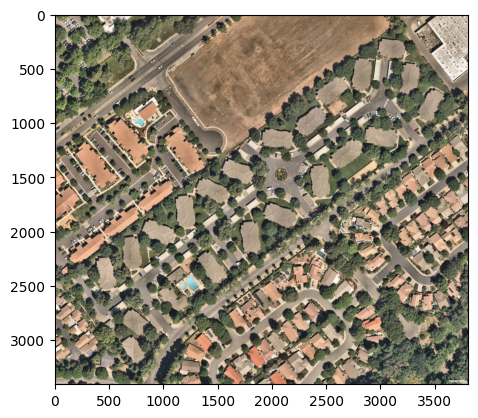

In [18]:
image = rasterio.open('/kaggle/input/datasets/deep262003/geospace-features/aerial_imagery_pack/1.tiff')

show(image)

plt.show()

In [19]:
print("=== TIFF Information ===")
print("Width:", image.width)
print("Height:", image.height)
print("Bands:", image.count)
print("CRS:", image.crs)
print("Resolution:", image.res)
print("Shape:", image.shape)

=== TIFF Information ===
Width: 3811
Height: 3407
Bands: 3
CRS: None
Resolution: (1.0, 1.0)
Shape: (3407, 3811)


# GeoJSON

In [20]:
gdf = gpd.read_file('/kaggle/input/datasets/deep262003/geospace-features/feature_layers/GeoJSON/1.geojson')

print("\n=== GeoJSON Information ===")
print("CRS:", gdf.crs)
print("Geometry Types:")
print(gdf.geometry.type.value_counts())

print("\nColumns:")
print(gdf.columns)

print("\nFirst few rows:")
print(gdf.head())


=== GeoJSON Information ===
CRS: EPSG:4326
Geometry Types:
Polygon    95
Name: count, dtype: int64

Columns:
Index(['id', 'Area', 'geometry'], dtype='object')

First few rows:
     id  Area                                           geometry
0  None  None  POLYGON ((-121.86547 39.75233, -121.86548 39.7...
1  None  None  POLYGON ((-121.86491 39.75249, -121.86492 39.7...
2  None  None  POLYGON ((-121.86495 39.75254, -121.86495 39.7...
3  None  None  POLYGON ((-121.86503 39.75246, -121.86506 39.7...
4  None  None  POLYGON ((-121.86522 39.75233, -121.86522 39.7...


In [22]:
print(gdf.geometry.iloc[0])
print(gdf.total_bounds)
print(image.width, image.height)

POLYGON ((-121.86547277245134 39.75232989994444, -121.86548090668724 39.75233482741427, -121.86549382225655 39.752346396336556, -121.86549963732331 39.752353619261584, -121.86550477906655 39.75236390274806, -121.86550734993817 39.75237069719448, -121.86550869658521 39.752376879528605, -121.86550869658521 39.75238134794832, -121.86550839052907 39.752387530282455, -121.8655069826708 39.75239444715133, -121.86550471785533 39.75240234339987, -121.86549975974577 39.752410300859644, -121.86549216955338 39.752419115276616, -121.86548268181288 39.7524273175813, -121.86546988866601 39.75243478535124, -121.86545752399776 39.75243949861588, -121.86544975017168 39.752441824642574, -121.86544167028946 39.75244311007839, -121.86543261102756 39.75244427309174, -121.86542147058388 39.75244427309174, -121.86540916712687 39.75244268159979, -121.86540029149866 39.752440110728166, -121.86538884499883 39.752436009575824, -121.86538058148291 39.752432887803145, -121.86537072647505 39.7524268891027, -121.865

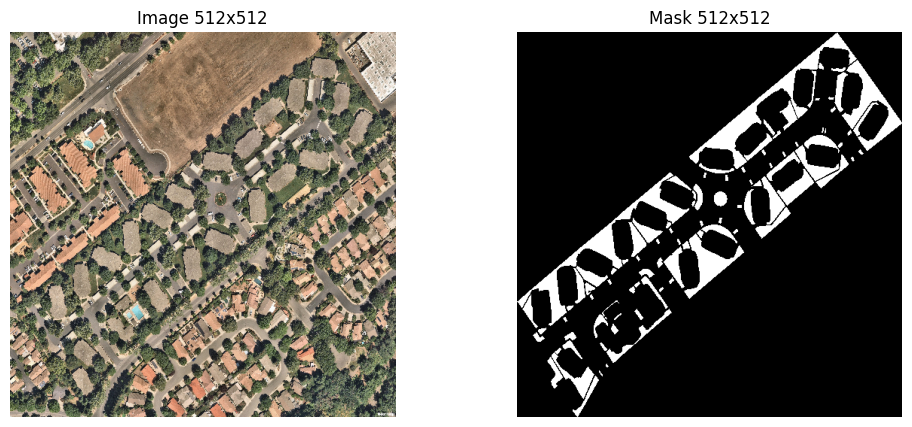

In [30]:
from PIL import Image
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import cv2

# -----------------------------
# Paths (Kaggle)
# -----------------------------
image_path = "/kaggle/input/datasets/deep262003/geospace-features/aerial_imagery_pack/1.tiff"
geojson_path = "/kaggle/input/datasets/deep262003/geospace-features/feature_layers/GeoJSON/1.geojson"

# -----------------------------
# Load image safely
# -----------------------------
image = np.array(Image.open(image_path))
H, W = image.shape[:2]

# -----------------------------
# Load GeoJSON
# -----------------------------
gdf = gpd.read_file(geojson_path)

# -----------------------------
# Geo bounds (lat/lon → pixel mapping)
# -----------------------------
minx, miny, maxx, maxy = gdf.total_bounds

def geo_to_pixel(x, y):
    px = (x - minx) / (maxx - minx) * W
    py = (maxy - y) / (maxy - miny) * H
    return int(px), int(py)

# -----------------------------
# Create mask
# -----------------------------
mask = np.zeros((H, W), dtype=np.uint8)

for geom in gdf.geometry:

    if geom.geom_type == "Polygon":
        polys = [geom]
    elif geom.geom_type == "MultiPolygon":
        polys = geom.geoms
    else:
        continue

    for poly in polys:
        coords = np.array(
            [geo_to_pixel(x, y) for x, y in poly.exterior.coords],
            dtype=np.int32
        )

        cv2.fillPoly(mask, [coords], 1)

TILE_SIZE = 512

image_512 = cv2.resize(image, (TILE_SIZE, TILE_SIZE), interpolation=cv2.INTER_LINEAR)

mask_512 = cv2.resize(mask, (TILE_SIZE, TILE_SIZE), interpolation=cv2.INTER_NEAREST)

# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image_512)
plt.title("Image 512x512")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask_512, cmap="gray")
plt.title("Mask 512x512")
plt.axis("off")

plt.show()